# Aktivitet: Steinen fra broen — hvor mye betyr luftmotstanden?
**TRES0312 Fysikk — Kapittel 3: Kinematikk (Plenumsregning)**

I videoen slippes en stein fra en bro, og den bruker $t_0 = 2.4\,\mathrm{s}$ på å nå vannoverflaten.

I oppgaven regnet vi ut broens høyde ved å anta at steinen faller **uten luftmotstand**:

$$h_0 = \tfrac{1}{2} g t_0^2$$

Her undersøker vi hvor god denne antakelsen egentlig er, ved å regne **numerisk** på fallet med luftmotstand inkludert, og sammenligne.

**Antakelser om steinen** (ingen av disse er oppgitt i oppgaven — vi må gjette oss fram til noe rimelig): den er kuleformet med diameter $4\,\mathrm{cm}$ (radius $r=0.02\,\mathrm{m}$) og har en tetthet omtrent som vanlig stein/granitt, $\rho_{\text{stein}} \approx 2500\,\mathrm{kg/m^3}$. Luftens tetthet er $\rho_{\text{luft}} \approx 1.225\,\mathrm{kg/m^3}$, og luftmotstandskoeffisienten for en kule er typisk $C_d \approx 0.47$.

Luftmotstandskraften på en kule som beveger seg med fart $v$ er

$$F_L = \tfrac{1}{2}\,\rho_{\text{luft}}\,C_d\,A\,v^2, \qquad A = \pi r^2$$

og peker alltid motsatt av bevegelsesretningen (oppover, når steinen faller nedover).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Parametere
# -------------------------
g = 9.81            # tyngdeakselerasjon [m/s^2]
t0 = 2.4             # observert falltid, uten luftmotstand antatt [s]
h0 = 0.5 * g * t0**2  # broens høyde ut fra a)

# Usikkerhet i tidtakingen: vi tror den egentlige falltiden ligger et sted i
# intervallet [t0 - 0.1 s, t0 + 0.2 s] (asymmetrisk, f.eks. pga. reaksjonstid)
t_lower = t0 - 0.1    # nedre grense for falltiden [s]
t_upper = t0 + 0.2    # øvre grense for falltiden [s]

# Antakelser om steinen (se diskusjon over)
r = 0.02              # radius [m]
rho_stein = 2500.0    # tetthet [kg/m^3]
rho_luft = 1.225      # lufttetthet [kg/m^3]
Cd = 0.47             # luftmotstandskoeffisient for kule

V = 4/3 * np.pi * r**3
m = rho_stein * V               # masse [kg]
A = np.pi * r**2                # tverrsnittsareal [m^2]
k = 0.5 * rho_luft * Cd * A     # luftmotstandskonstant

print(f"Høyde beregnet uten luftmotstand: h0 = {h0:.2f} m")
print(f"Masse: m = {m:.3f} kg,  k = {k:.6f} kg/m")

Høyde beregnet uten luftmotstand: h0 = 28.25 m
Masse: m = 0.084 kg,  k = 0.000362 kg/m


In [ ]:
def simuler_fall(k, m, g=9.81, dt=1e-4, h_maks=100.0):
    """
    Simulerer et fritt fall med luftmotstand numerisk (Eulers metode).
    Bevegelsesligningen er m*dv/dt = m*g - k*v*|v|, dh/dt = v.
    Luftmotstanden er proporsjonal med v^2, men vi bruker v*|v| for at
    kraften alltid skal peke motsatt av bevegelsen (relevant om v<0).

    Returnerer tidspunktene, høyden falt, og farten ved hvert tidssteg.
    """
    t, v, h = 0.0, 0.0, 0.0
    ts, hs, vs = [t], [h], [v]
    while h < h_maks:
        a = g - (k / m) * v * abs(v)
        v += a * dt
        h += v * dt
        t += dt
        ts.append(t); hs.append(h); vs.append(v)
    return np.array(ts), np.array(hs), np.array(vs)

# Vi simulerer en god del forbi h0 (og forbi t_upper + litt ekstra margin), slik
# at kurven dekker langt nok i tid til å regne ut høydeusikkerheten under uten
# å måtte ekstrapolere utenfor det vi har simulert.
h_maks_sim = max(h0, 0.5 * g * (t_upper + 0.25)**2) * 1.05
t_u, h_u, v_u = simuler_fall(k=0.0, m=m, h_maks=h_maks_sim)   # uten luftmotstand
t_m, h_m, v_m = simuler_fall(k=k,   m=m, h_maks=h_maks_sim)   # med luftmotstand

# Finn tidspunktet der hver kurve passerer h0 (interpolasjon)
t_stopp_u = np.interp(h0, h_u, t_u)
v_stopp_u = np.interp(h0, h_u, v_u)
t_stopp_m = np.interp(h0, h_m, t_m)
v_stopp_m = np.interp(h0, h_m, v_m)

print(f"Uten luftmotstand: bruker {t_stopp_u:.4f} s, treffer vannet i {v_stopp_u:.2f} m/s")
print(f"Med luftmotstand:  bruker {t_stopp_m:.4f} s, treffer vannet i {v_stopp_m:.2f} m/s")
print(f"Luftmotstanden øker falltiden med {(t_stopp_m - t_stopp_u)/t_stopp_u*100:.1f} %")
print(f"Luftmotstanden reduserer treffhastigheten med {(v_stopp_u - v_stopp_m)/v_stopp_u*100:.1f} %")

# Usikkerheten i DEN BEREGNEDE BRUHØYDEN h0 (ett tall), som følge av at den
# egentlige falltiden kan avvike fra den observerte t0 (se a))
h_lower_u = np.interp(t_lower, t_u, h_u)
h_upper_u = np.interp(t_upper, t_u, h_u)
h_lower_m = np.interp(t_lower, t_m, h_m)
h_upper_m = np.interp(t_upper, t_m, h_m)

print(f"Usikkerhet i beregnet høyde (uten luftmotstand): {h_lower_u:.2f} m – {h_upper_u:.2f} m")
print(f"Usikkerhet i beregnet høyde (med luftmotstand):  {h_lower_m:.2f} m – {h_upper_m:.2f} m")

# Høydeusikkerhet SOM FUNKSJON AV TIDEN — dette er omhyllingskurvene til plottet
# under. Tidtakingsfeilen er den samme feilen gjennom hele fallet (en fast
# forskyvning i når klokka egentlig startet), så ved et gitt avlest tidspunkt t
# kan den virkelige falltiden være hvor som helst i [t + (t_lower - t0), t + (t_upper - t0)].
# h_min(t) og h_max(t) er høyden kurven har ved disse forskjøvne tidspunktene,
# altså en skygge som følger kurven — ikke et fast, vannrett bånd.
dt_lo = t_lower - t0   # nedre tidsforskyvning [s] (negativ)
dt_hi = t_upper - t0   # øvre tidsforskyvning [s] (positiv)

def hoyde_omhylling(t_arr, h_arr):
    h_min = np.interp(t_arr + dt_lo, t_arr, h_arr)
    h_max = np.interp(t_arr + dt_hi, t_arr, h_arr)
    return h_min, h_max

h_env_lo_u, h_env_hi_u = hoyde_omhylling(t_u, h_u)
h_env_lo_m, h_env_hi_m = hoyde_omhylling(t_m, h_m)


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4.2))

axs[0].fill_between(t_u, h_env_lo_u, h_env_hi_u, color="gray", alpha=0.25, zorder=0,
                     label="Usikkerhet i høyde (uten luftmotstand)")
axs[0].fill_between(t_m, h_env_lo_m, h_env_hi_m, color="royalblue", alpha=0.20, zorder=0,
                     label="Usikkerhet i høyde (med luftmotstand)")

axs[0].plot(t_u, h_u, "--", color="gray", linewidth=2, label="Uten luftmotstand", zorder=2)
axs[0].plot(t_m, h_m, "-", color="royalblue", linewidth=2.5, label="Med luftmotstand", zorder=2)
axs[0].axhline(h0, color="black", linewidth=1, linestyle=":", zorder=2)
axs[0].set_xlim(0, t_upper * 1.02)
axs[0].set_xlabel("Tid [s]")
axs[0].set_ylabel("Fallhøyde [m]")
axs[0].set_title("Høyde falt")
axs[0].legend(fontsize=8)
axs[0].grid(True, alpha=0.3)

axs[1].plot(t_u, v_u, "--", color="gray", linewidth=2, label="Uten luftmotstand")
axs[1].plot(t_m, v_m, "-", color="tomato", linewidth=2.5, label="Med luftmotstand")
axs[1].set_xlim(0, t_upper * 1.02)
axs[1].set_xlabel("Tid [s]")
axs[1].set_ylabel("Fart [m/s]")
axs[1].set_title("Fart")
axs[1].legend(fontsize=9)
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Konklusjon

For en stein på denne størrelsen og tettheten utgjør luftmotstanden fortsatt bare en liten forskjell over et fall på under $30\,\mathrm{m}$ — falltiden øker med rundt $2\,\%$, og treffhastigheten reduseres med rundt $6\,\%$. Dette henger sammen med at steinen er tung nok til at luftmotstanden er liten sammenlignet med tyngdekraften ved disse fartene (langt under steinens terminalfart). Antakelsen om null luftmotstand i a) er derfor fortsatt god i dette tilfellet — men usikkerheten i selve tidtakingen (de fargede feltene i figuren over) er faktisk en like stor feilkilde som luftmotstanden her.

### Prøv selv
- Hva skjer med resultatet dersom steinen er mye lettere, f.eks. en liten isopor-kule med samme størrelse? Prøv å endre `rho_stein`.
- Hvor stor må falltiden/høyden være før luftmotstanden begynner å utgjøre mer enn f.eks. 10 %?

### Enda mer luftmotstand: fall fra Preikestolen

Bruhøyden i denne oppgaven er ganske lav (rundt 28 m), og luftmotstanden fikk derfor liten
betydning. Hva skjer om steinen i stedet faller fra et mye høyere punkt, som Preikestolen —
som stikker $604\,\mathrm{m}$ rett ned i Lysefjorden?

Her ser vi at kurvene med og uten luftmotstand begynner å skille seg klart fra hverandre,
fordi steinen nå får tid til å nærme seg terminalfarten sin. Vi ser bort fra
usikkerhetsskyggene her, og fokuserer bare på selve sammenligningen.

In [4]:
h_preikestolen = 604.0   # høyde over Lysefjorden [m] (Preikestolen)

t_u_p, h_u_p, v_u_p = simuler_fall(k=0.0, m=m, h_maks=h_preikestolen)   # uten luftmotstand
t_m_p, h_m_p, v_m_p = simuler_fall(k=k,   m=m, h_maks=h_preikestolen)   # med luftmotstand

t_stopp_u_p = np.interp(h_preikestolen, h_u_p, t_u_p)
v_stopp_u_p = np.interp(h_preikestolen, h_u_p, v_u_p)
t_stopp_m_p = np.interp(h_preikestolen, h_m_p, t_m_p)
v_stopp_m_p = np.interp(h_preikestolen, h_m_p, v_m_p)

print(f"Fall fra Preikestolen ({h_preikestolen:.0f} m):")
print(f"Uten luftmotstand: bruker {t_stopp_u_p:.2f} s, treffer vannet i {v_stopp_u_p:.1f} m/s")
print(f"Med luftmotstand:  bruker {t_stopp_m_p:.2f} s, treffer vannet i {v_stopp_m_p:.1f} m/s")
print(f"Luftmotstanden øker falltiden med {(t_stopp_m_p - t_stopp_u_p)/t_stopp_u_p*100:.1f} %")
print(f"Luftmotstanden reduserer treffhastigheten med {(v_stopp_u_p - v_stopp_m_p)/v_stopp_u_p*100:.1f} %")

Fall fra Preikestolen (604 m):
Uten luftmotstand: bruker 11.10 s, treffer vannet i 108.9 m/s
Med luftmotstand:  bruker 16.03 s, treffer vannet i 47.5 m/s
Luftmotstanden øker falltiden med 44.5 %
Luftmotstanden reduserer treffhastigheten med 56.3 %


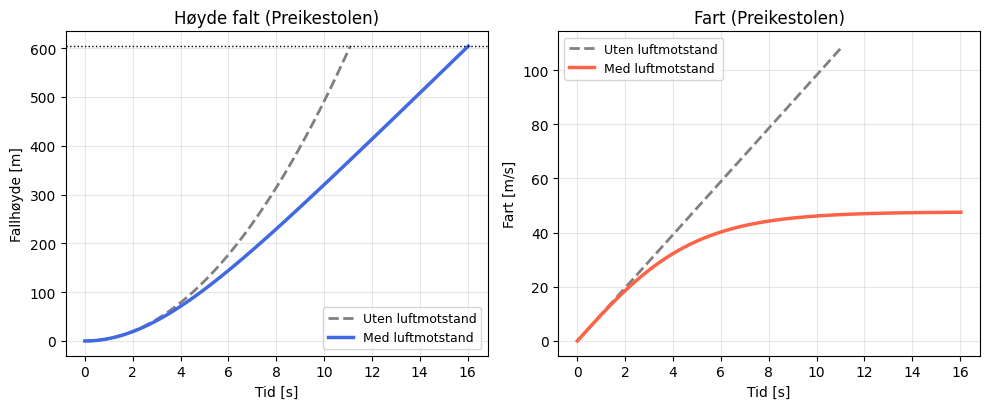

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4.2))

axs[0].plot(t_u_p, h_u_p, "--", color="gray", linewidth=2, label="Uten luftmotstand")
axs[0].plot(t_m_p, h_m_p, "-", color="royalblue", linewidth=2.5, label="Med luftmotstand")
axs[0].axhline(h_preikestolen, color="black", linewidth=1, linestyle=":")
axs[0].set_xlabel("Tid [s]")
axs[0].set_ylabel("Fallhøyde [m]")
axs[0].set_title("Høyde falt (Preikestolen)")
axs[0].legend(fontsize=9)
axs[0].grid(True, alpha=0.3)

axs[1].plot(t_u_p, v_u_p, "--", color="gray", linewidth=2, label="Uten luftmotstand")
axs[1].plot(t_m_p, v_m_p, "-", color="tomato", linewidth=2.5, label="Med luftmotstand")
axs[1].set_xlabel("Tid [s]")
axs[1].set_ylabel("Fart [m/s]")
axs[1].set_title("Fart (Preikestolen)")
axs[1].legend(fontsize=9)
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Til forelesningen: figurer for lysbildene

Cellen under genererer figurene som brukes i F7-lysbildene (en lys og en mørk variant av hver, med gjennomsiktig bakgrunn). Dette er ikke nødvendig for å løse oppgaven — det er bare for å holde lysbildene og notatboken synkronisert.

In [ ]:
from pathlib import Path

# .../TRES0312 Python/Kap3_Kinematikk -> repo-rot -> TRES0312 Foiler/Images
bilde_mappe = Path.cwd().resolve().parents[1] / "TRES0312 Foiler" / "Images"

FARGE_LYS = "black"
FARGE_MORK = "#EBEBEB"

def sett_tema(farge):
    plt.rcParams.update({
        "text.color": farge,
        "axes.edgecolor": farge,
        "axes.labelcolor": farge,
        "xtick.color": farge,
        "ytick.color": farge,
        "legend.labelcolor": farge,
        "legend.frameon": False,  # ingen hvit boks bak legenden
    })

def lagre_begge_temaer(tegn_figur, filnavn_stem):
    for farge, suffiks in [(FARGE_LYS, "lys"), (FARGE_MORK, "mork")]:
        with plt.rc_context():
            sett_tema(farge)
            fig = tegn_figur()
            fig.savefig(bilde_mappe / f"{filnavn_stem}_{suffiks}.png",
                        dpi=200, transparent=True, bbox_inches="tight")
            plt.close(fig)

def tegn_oppgave():
    fig, axs = plt.subplots(2, 1, figsize=(4.6, 6.4))
    axs[0].plot(t_u, h_u, "--", color="gray", linewidth=2, label="Uten luftmotstand", zorder=2)
    axs[0].plot(t_m, h_m, "-", color="royalblue", linewidth=2.5, label="Med luftmotstand", zorder=2)
    axs[0].axhline(h0, color=FARGE_LYS if plt.rcParams["text.color"] == FARGE_LYS else FARGE_MORK,
                   linewidth=1, linestyle=":", zorder=2)
    axs[0].set_xlim(0, t_upper * 1.02)
    axs[0].set_xlabel("Tid [s]"); axs[0].set_ylabel("Fallhøyde [m]")
    axs[0].legend(fontsize=8); axs[0].grid(True, alpha=0.3)
    axs[1].plot(t_u, v_u, "--", color="gray", linewidth=2, label="Uten luftmotstand")
    axs[1].plot(t_m, v_m, "-", color="tomato", linewidth=2.5, label="Med luftmotstand")
    axs[1].set_xlim(0, t_upper * 1.02)
    axs[1].set_xlabel("Tid [s]"); axs[1].set_ylabel("Fart [m/s]")
    axs[1].legend(fontsize=8); axs[1].grid(True, alpha=0.3)
    fig.tight_layout()
    return fig

def tegn_preikestolen():
    fig, axs = plt.subplots(2, 1, figsize=(4.6, 6.4))
    axs[0].plot(t_u_p, h_u_p, "--", color="gray", linewidth=2, label="Uten luftmotstand")
    axs[0].plot(t_m_p, h_m_p, "-", color="royalblue", linewidth=2.5, label="Med luftmotstand")
    axs[0].axhline(h_preikestolen,
                   color=FARGE_LYS if plt.rcParams["text.color"] == FARGE_LYS else FARGE_MORK,
                   linewidth=1, linestyle=":")
    axs[0].set_xlabel("Tid [s]"); axs[0].set_ylabel("Fallhøyde [m]")
    axs[0].legend(fontsize=8); axs[0].grid(True, alpha=0.3)
    axs[1].plot(t_u_p, v_u_p, "--", color="gray", linewidth=2, label="Uten luftmotstand")
    axs[1].plot(t_m_p, v_m_p, "-", color="tomato", linewidth=2.5, label="Med luftmotstand")
    axs[1].set_xlabel("Tid [s]"); axs[1].set_ylabel("Fart [m/s]")
    axs[1].legend(fontsize=8); axs[1].grid(True, alpha=0.3)
    fig.tight_layout()
    return fig

def tegn_usikkerhet():
    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    ax.fill_between(t_u, h_env_lo_u, h_env_hi_u, color="gray", alpha=0.25, zorder=0,
                    label="Usikkerhet (uten luftmotstand)")
    ax.fill_between(t_m, h_env_lo_m, h_env_hi_m, color="royalblue", alpha=0.20, zorder=0,
                    label="Usikkerhet (med luftmotstand)")
    ax.plot(t_u, h_u, "--", color="gray", linewidth=2, label="Uten luftmotstand", zorder=2)
    ax.plot(t_m, h_m, "-", color="royalblue", linewidth=2.5, label="Med luftmotstand", zorder=2)
    ax.axhline(h0, color=FARGE_LYS if plt.rcParams["text.color"] == FARGE_LYS else FARGE_MORK,
               linewidth=1, linestyle=":", zorder=2)
    ax.set_xlim(0, t_upper * 1.02)
    ax.set_xlabel("Tid [s]"); ax.set_ylabel("Fallhøyde [m]")
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return fig

lagre_begge_temaer(tegn_oppgave, "Steinkast_oppgave")
lagre_begge_temaer(tegn_preikestolen, "Steinkast_preikestolen")
lagre_begge_temaer(tegn_usikkerhet, "Steinkast_usikkerhet")

print("Figurer lagret i", bilde_mappe)